# F1 Qualifying Dataset — Exploratory Data Analysis

Ground effect regulatory era · 2022–2025


## Imports and configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import DATA_PATH_WITH_FP

# ── paths ────────────────────────────────────────────────────────────────
MERGED_CSV = DATA_PATH_WITH_FP

# ── plot style ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
TEAM_PALETTE = {
    "Ferrari":        "#DC0000",
    "McLaren":        "#FF8000",
    "Red Bull Racing":"#3671C6",
    "Mercedes":       "#27F4D2",
    "Aston Martin":   "#358C75",
    "Alpine":         "#FF87BC",
    "Williams":       "#64C4FF",
    "Racing Bulls":   "#6692FF",
    "Kick Sauber":    "#52E252",
    "Haas F1 Team":   "#B6BABD",
}
%matplotlib inline


## Load data

In [3]:
df = pd.read_csv(MERGED_CSV)

# convenience: best lap per driver per session (used in several sections)
BEST = (
    df.sort_values("LapTime_s")
      .groupby(["Year","Round","Circuit","Driver","Team","SubSession"], as_index=False)
      .first()
)

print(f"Shape : {df.shape}")
print(f"Seasons: {sorted(df.Year.unique())}")
print(f"Rounds : {df.Round.max()} max per season")
df.head(3)


Shape : (4112, 30)
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Rounds : 24 max per season


,Year,Round,Circuit,Driver,Team,SubSession,LapTime_s,GridPosition,Sector1_s,Sector2_s,...,Humidity_pct,Pressure_hPa,WindSpeed_ms,Rainfall,FP1_s,FP2_s,FP3_s,IsSprintWeekend,SubSession_ord,Wet
0,2022,1,BAHRAIN GRAND PRIX,LEC,Ferrari,Q1,91.471,1.0,29.367,39.067,...,56.0,1013.7,0.5,0.0,94.557,92.023,92.640,0,1,0
1,2022,1,BAHRAIN GRAND PRIX,SAI,Ferrari,Q1,91.567,3.0,29.394,39.218,...,56.0,1013.7,0.5,0.0,94.611,92.520,93.053,0,1,0
2,2022,1,BAHRAIN GRAND PRIX,VER,Red Bull Racing,Q1,91.785,2.0,29.422,39.518,...,56.0,1013.7,0.5,0.0,94.742,91.936,92.544,0,1,0


## Schema, dtypes, and missing values

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4112 entries, 0 to 4111
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             4112 non-null   int64  
 1   Round            4112 non-null   int64  
 2   Circuit          4112 non-null   object 
 3   Driver           4112 non-null   object 
 4   Team             4112 non-null   object 
 5   SubSession       4112 non-null   object 
 6   LapTime_s        4112 non-null   float64
 7   GridPosition     4112 non-null   float64
 8   Sector1_s        4111 non-null   float64
 9   Sector2_s        4112 non-null   float64
 10  Sector3_s        4112 non-null   float64
 11  TyreLife         4108 non-null   float64
 12  Compound         4112 non-null   object 
 13  FreshTyre        4112 non-null   bool   
 14  SpeedI1          4112 non-null   float64
 15  SpeedI2          4112 non-null   float64
 16  SpeedFL          4102 non-null   float64
 17  SpeedST       

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].rename("missing").to_frame()
missing["pct"] = (missing["missing"] / len(df) * 100).round(2)
missing


,missing,pct
Sector1_s,1,0.02
TyreLife,4,0.10
SpeedFL,10,0.24
FP1_s,327,7.95
FP2_s,862,20.96
FP3_s,66,1.61


## Descriptive statistics

In [6]:
NUM_COLS = [
    "LapTime_s", "Sector1_s", "Sector2_s", "Sector3_s",
    "TyreLife", "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp_C", "TrackTemp_C", "Humidity_pct",
    "Pressure_hPa", "WindSpeed_ms", "GridPosition",
]
df[NUM_COLS].describe().round(3).T


,count,mean,std,min,25%,50%,75%,max
LapTime_s,4112.0,85.029,11.609,63.971,76.245,84.504,91.402,128.169
Sector1_s,4111.0,26.259,5.089,16.254,23.364,27.022,29.554,59.055
Sector2_s,4112.0,32.793,7.050,16.915,27.774,31.289,38.247,59.600
Sector3_s,4112.0,25.981,5.980,15.941,21.525,25.230,29.862,62.164
TyreLife,4108.0,2.915,1.772,1.000,2.000,2.000,3.000,19.000
SpeedI1,4112.0,271.512,43.108,107.000,238.000,284.000,308.000,345.000
SpeedI2,4112.0,264.721,43.986,159.000,236.000,270.000,298.000,347.000
SpeedFL,4102.0,276.700,33.464,183.000,256.000,282.000,301.000,346.000
SpeedST,4112.0,315.776,21.681,100.000,303.000,320.000,329.000,355.000
AirTemp_C,4112.0,23.830,5.502,11.700,19.800,24.400,27.800,35.500


In [9]:
# Categorical value counts
for col in ["SubSession", "Compound", "Team", "Year"]:
    print(f"── {col} ──")
    print(df[col].value_counts().to_string(), "\n")


── SubSession ──
SubSession
Q1    1831
Q2    1371
Q3     910 

── Compound ──
Compound
SOFT            3619
INTERMEDIATE     283
MEDIUM            85
WET               80
HARD              40
NONE               5 

── Team ──
Team
Ferrari            518
Mercedes           512
McLaren            498
Red Bull Racing    491
Aston Martin       383
Alpine             381
Racing Bulls       372
Haas F1 Team       343
Williams           314
Kick Sauber        300 

── Year ──
Year
2024    1074
2025    1069
2023     987
2022     982 



In [53]:
print(df['Driver'].value_counts().to_string())

Driver
VER    271
LEC    266
RUS    265
NOR    257
SAI    247
HAM    246
ALO    244
PIA    195
GAS    190
TSU    184
OCO    177
PER    175
ALB    175
STR    163
HUL    139
BOT    123
MAG    117
ZHO    100
RIC     92
LAW     69
HAD     61
ANT     60
BEA     50
SAR     44
MSC     41
BOR     40
COL     36
VET     35
LAT     24
DEV     16
DOO     10


## Lap time distribution

C:\Users\Yanna\AppData\Local\Temp\ipykernel_23124\3159106411.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="SubSession", y="LapTime_s",


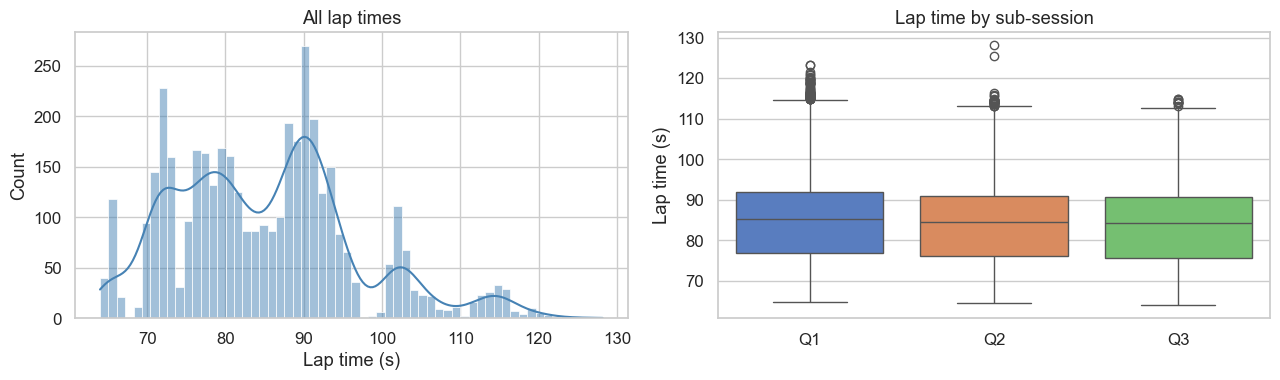

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# histogram + KDE
sns.histplot(df["LapTime_s"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set(title="All lap times", xlabel="Lap time (s)", ylabel="Count")

# per sub-session
sns.boxplot(data=df, x="SubSession", y="LapTime_s",
            order=["Q1","Q2","Q3"], ax=axes[1], palette="muted")
axes[1].set(title="Lap time by sub-session", xlabel="", ylabel="Lap time (s)")

plt.tight_layout()
plt.show()


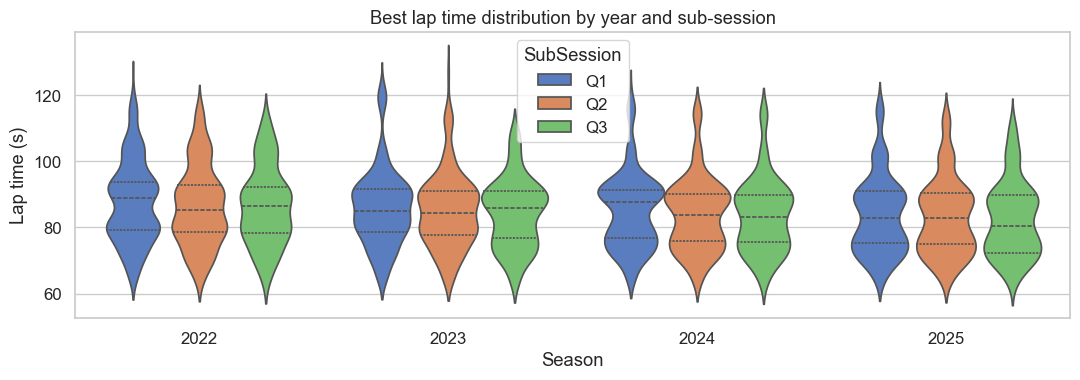

In [11]:
# Best lap per driver per session, by year
fig, ax = plt.subplots(figsize=(11, 4))
sns.violinplot(
    data=BEST, x="Year", y="LapTime_s", hue="SubSession",
    split=False, inner="quartile", palette="muted", ax=ax
)
ax.set(title="Best lap time distribution by year and sub-session",
       xlabel="Season", ylabel="Lap time (s)")
plt.tight_layout()
plt.show()


## Sector time analysis

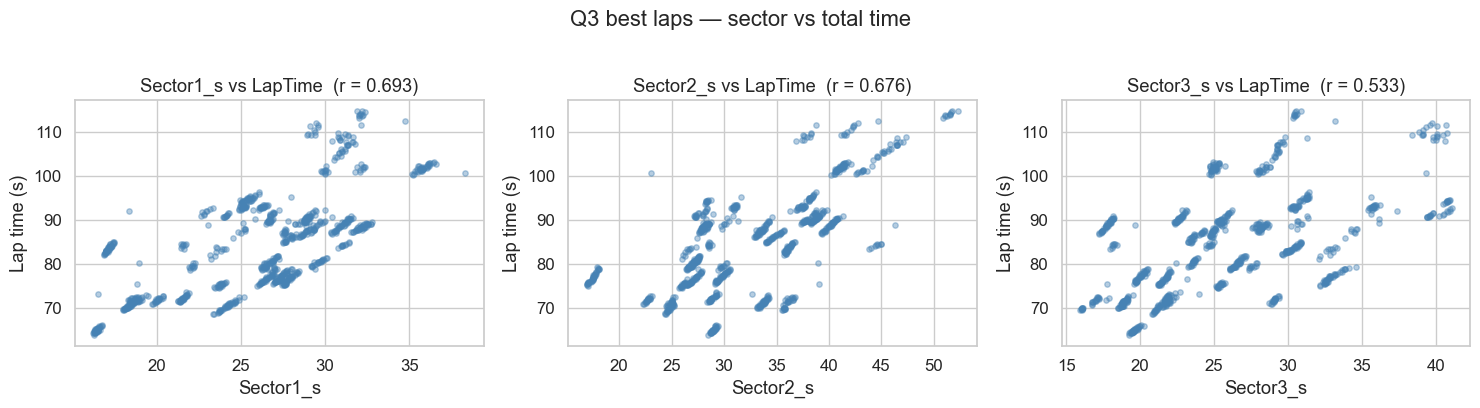

In [13]:
# Sector time scatter — fastest Q3 laps only
q3_best = BEST[BEST.SubSession == "Q3"].dropna(subset=["Sector1_s","Sector2_s","Sector3_s"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, s in zip(axes, ["Sector1_s","Sector2_s","Sector3_s"]):
    r, p = stats.pearsonr(q3_best[s], q3_best["LapTime_s"])
    ax.scatter(q3_best[s], q3_best["LapTime_s"], alpha=0.4, s=15, color="steelblue")
    ax.set(xlabel=s, ylabel="Lap time (s)",
            title=f"{s} vs LapTime  (r = {r:.3f})")
plt.suptitle("Q3 best laps — sector vs total time", y=1.02)
plt.tight_layout()
plt.show()


## Team performance

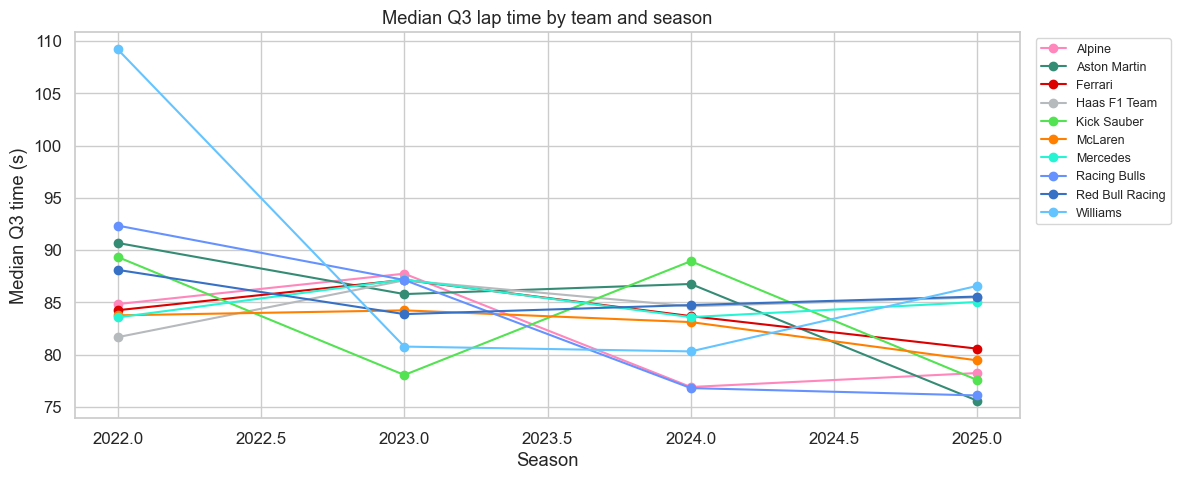

In [14]:
# Median best Q3 lap time per team per year
q3 = BEST[BEST.SubSession == "Q3"]
team_year = (
    q3.groupby(["Team","Year"])["LapTime_s"]
      .median()
      .reset_index()
      .rename(columns={"LapTime_s": "MedianQ3_s"})
)

fig, ax = plt.subplots(figsize=(12, 5))
for team, grp in team_year.groupby("Team"):
    ax.plot(grp["Year"], grp["MedianQ3_s"], marker="o",
            label=team, color=TEAM_PALETTE.get(team))
ax.set(title="Median Q3 lap time by team and season",
       xlabel="Season", ylabel="Median Q3 time (s)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


C:\Users\Yanna\AppData\Local\Temp\ipykernel_23124\470179367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=q3, x="Team", y="GridPosition",


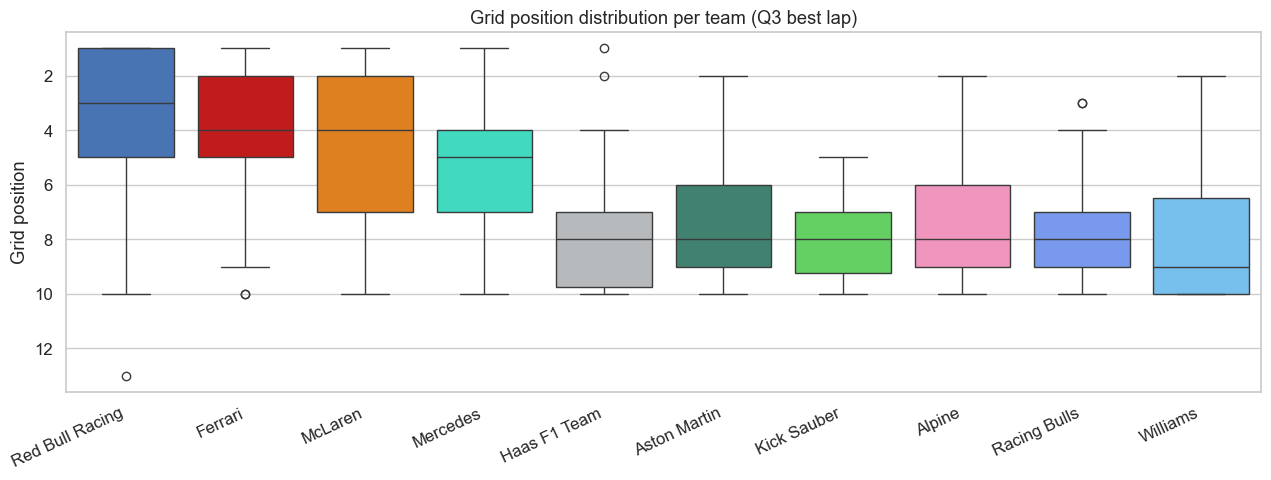

In [15]:
# Grid position distribution per team (Q3 only)
fig, ax = plt.subplots(figsize=(13, 5))
order = (
    q3.groupby("Team")["GridPosition"].median()
      .sort_values()
      .index.tolist()
)
sns.boxplot(data=q3, x="Team", y="GridPosition",
            order=order, palette=TEAM_PALETTE, ax=ax)
ax.set(title="Grid position distribution per team (Q3 best lap)",
       xlabel="", ylabel="Grid position")
ax.invert_yaxis()          # P1 at top
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Weather and track conditions

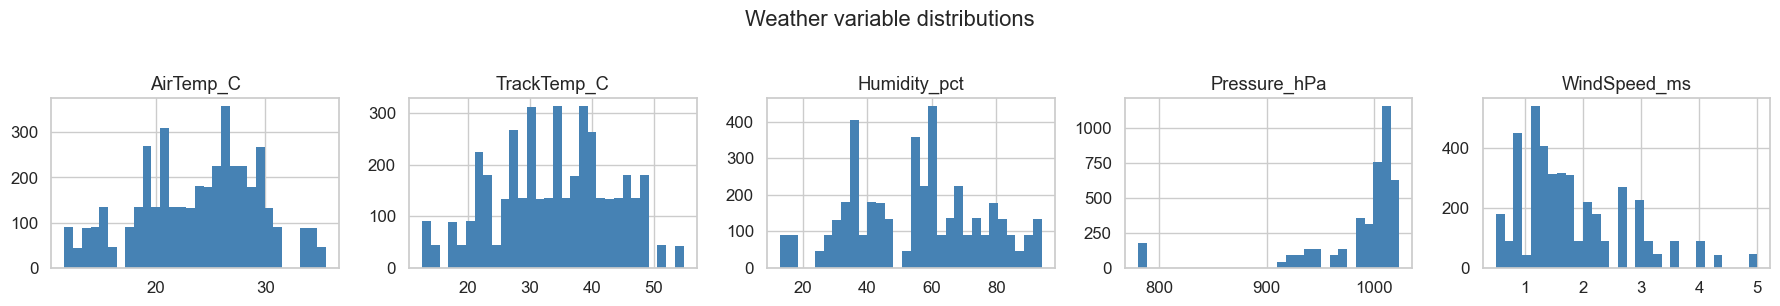

In [16]:
WEATHER = ["AirTemp_C","TrackTemp_C","Humidity_pct","Pressure_hPa","WindSpeed_ms"]

fig, axes = plt.subplots(1, len(WEATHER), figsize=(18, 3))
for ax, col in zip(axes, WEATHER):
    ax.hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="none")
    ax.set(title=col, xlabel="")
plt.suptitle("Weather variable distributions", y=1.02)
plt.tight_layout()
plt.show()


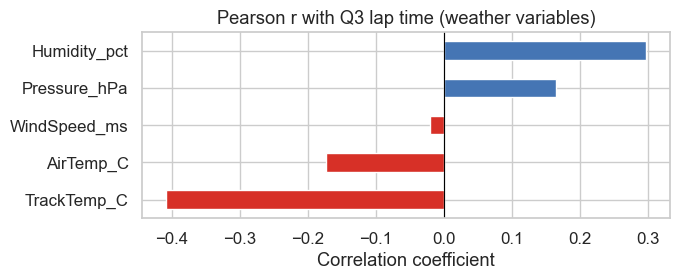

In [17]:
# Correlation of weather variables with best Q3 lap time
weather_corr = (
    BEST[BEST.SubSession == "Q3"][WEATHER + ["LapTime_s"]]
    .corr()["LapTime_s"]
    .drop("LapTime_s")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 3))
weather_corr.plot.barh(ax=ax, color=["#d73027" if v<0 else "#4575b4" for v in weather_corr])
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Pearson r with Q3 lap time (weather variables)",
        xlabel="Correlation coefficient")
plt.tight_layout()
plt.show()


In [18]:
# Wet vs dry session breakdown
print("Wet sessions (Wet == 1):")
print(df[df.Wet == 1][["Year","Round","Circuit","SubSession"]].drop_duplicates().to_string(index=False))


Wet sessions (Wet == 1):
 Year  Round                    Circuit SubSession
 2022      9       GRAND PRIX DU CANADA         Q1
 2022      9       GRAND PRIX DU CANADA         Q2
 2022      9       GRAND PRIX DU CANADA         Q3
 2022     10         BRITISH GRAND PRIX         Q1
 2022     10         BRITISH GRAND PRIX         Q2
 2022     10         BRITISH GRAND PRIX         Q3
 2024     13       GRAND PRIX DE MONACO         Q1
 2024     13       GRAND PRIX DE MONACO         Q2
 2024     13       GRAND PRIX DE MONACO         Q3
 2024     21 GRANDE PRÊMIO DE SÃO PAULO         Q1
 2024     21 GRANDE PRÊMIO DE SÃO PAULO         Q2
 2024     21 GRANDE PRÊMIO DE SÃO PAULO         Q3


## Tyre compound and life

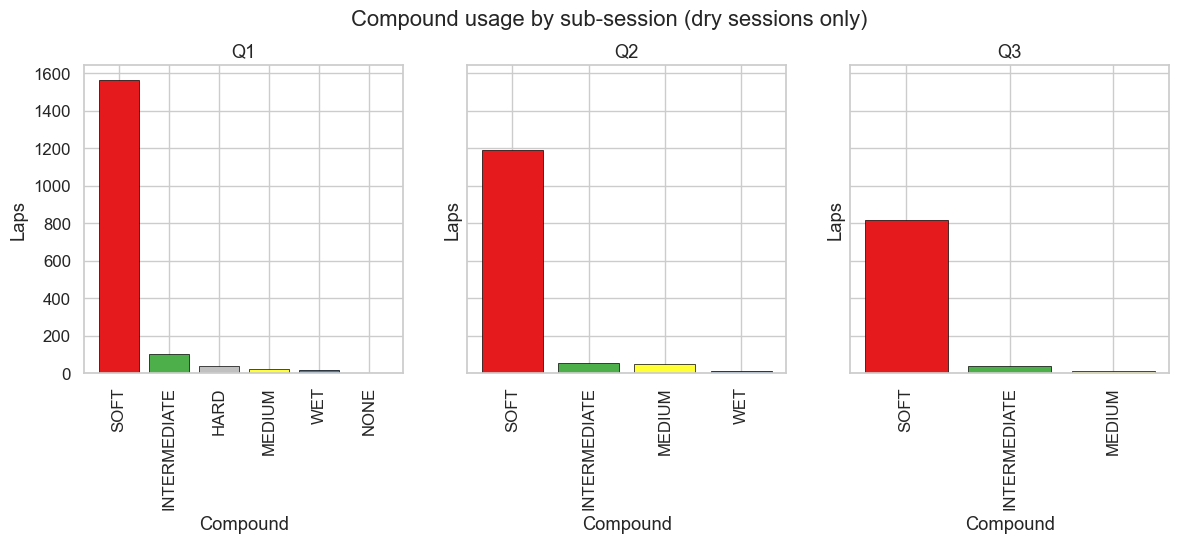

In [31]:
# Compound usage per sub-session (dry only)
dry = df[df.Wet == 0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, session in zip(axes, ["Q1","Q2","Q3"]):
       counts = dry[dry.SubSession == session]["Compound"].value_counts()
       ax.set(title=session, xlabel="Compound", ylabel="Laps")
       ax.tick_params(axis="x", rotation=90)
       ax.bar(counts.index, counts.values,
              color=[{"SOFT":"#e41a1c","MEDIUM":"#ffff33","HARD":"#c0c0c0",
                     "INTERMEDIATE":"#4daf4a","WET":"#377eb8", "NONE":"#999999"}.get(c,"grey")
                     for c in counts.index],
              edgecolor="black", linewidth=0.5)
plt.suptitle("Compound usage by sub-session (dry sessions only)", y=1.02)
plt.show()


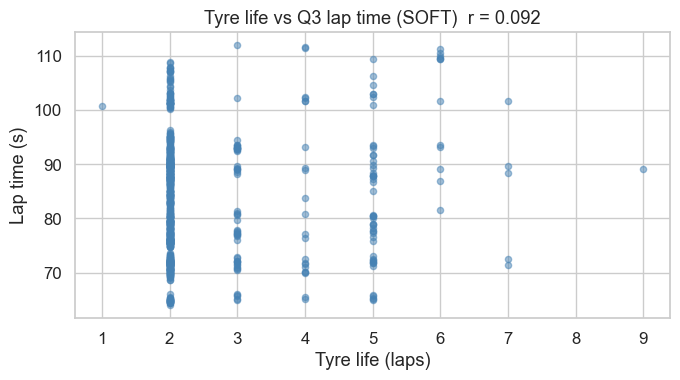

In [25]:
# Tyre life vs lap time (Q3 soft only)
q3_soft = BEST[(BEST.SubSession=="Q3") & (BEST.Compound=="SOFT")]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(q3_soft["TyreLife"], q3_soft["LapTime_s"], alpha=0.5, s=20, color="steelblue")
r, _ = stats.pearsonr(q3_soft["TyreLife"].dropna(), 
                            q3_soft.loc[q3_soft["TyreLife"].notna(), "LapTime_s"])
ax.set(title=f"Tyre life vs Q3 lap time (SOFT)  r = {r:.3f}",
       xlabel="Tyre life (laps)", ylabel="Lap time (s)")
plt.tight_layout()
plt.show()


## Q1 → Q2 → Q3 progression

Mean improvement Q1→Q2: 0.888 s
Mean improvement Q2→Q3: 0.458 s


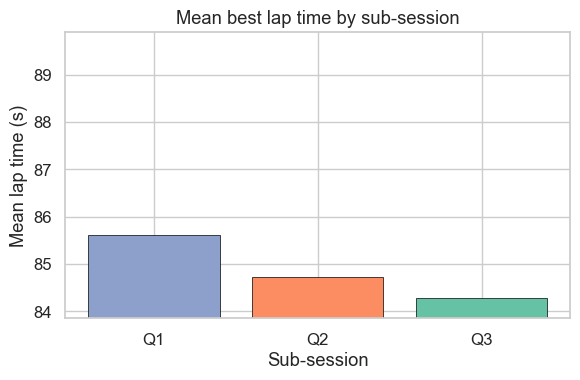

In [44]:
# Mean lap time improvement per session across all rounds
progression = (
       BEST.groupby("SubSession")["LapTime_s"]
              .mean()
              .reindex(["Q1","Q2","Q3"])
)
delta_q1q2 = progression["Q1"] - progression["Q2"]
delta_q2q3 = progression["Q2"] - progression["Q3"]
print(f"Mean improvement Q1→Q2: {delta_q1q2:.3f} s")
print(f"Mean improvement Q2→Q3: {delta_q2q3:.3f} s")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(progression.index, progression.values, color=["#8da0cb","#fc8d62","#66c2a5"],
       edgecolor="black", linewidth=0.5)
ax.set(title="Mean best lap time by sub-session",
       xlabel="Sub-session", ylabel="Mean lap time (s)")
ax.set_ylim(bottom=progression.min() * 0.995)
plt.tight_layout()
plt.show()


In [33]:
# Drivers who made Q3 vs those eliminated in Q1/Q2 (2022-2025 aggregate)
q_counts = (
    BEST.groupby("Driver")["SubSession"]
        .apply(lambda x: x.value_counts())
        .unstack(fill_value=0)
        .reindex(columns=["Q1","Q2","Q3"], fill_value=0)
)
q_counts["Q3_rate"] = q_counts["Q3"] / q_counts[["Q1","Q2","Q3"]].sum(axis=1)
q_counts.sort_values("Q3_rate", ascending=False).head(15)


,Q1,Q2,Q3,Q3_rate
Driver,,,,
VER,92,91,88,0.324723
LEC,92,90,84,0.315789
RUS,92,90,83,0.313208
PIA,70,64,61,0.312821
NOR,92,87,78,0.303502
HAM,92,83,71,0.288618
SAI,91,87,69,0.279352
ALO,92,85,67,0.274590
PER,68,59,48,0.274286


## Feature correlation matrix

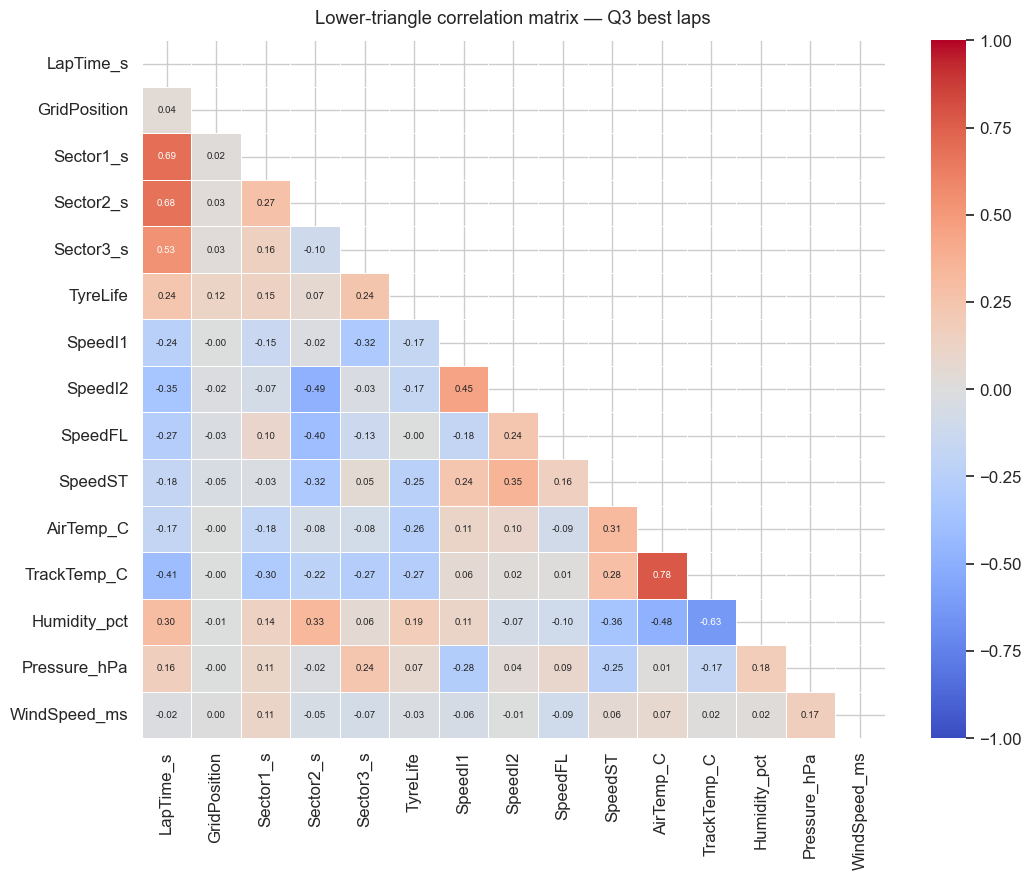

In [45]:
FEAT_COLS = [
    "LapTime_s","GridPosition",
    "Sector1_s","Sector2_s","Sector3_s",
    "TyreLife","SpeedI1","SpeedI2","SpeedFL","SpeedST",
    "AirTemp_C","TrackTemp_C","Humidity_pct","Pressure_hPa","WindSpeed_ms",
]

corr_mat = BEST[BEST.SubSession == "Q3"][FEAT_COLS].corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Lower-triangle correlation matrix — Q3 best laps", pad=12)
plt.tight_layout()
plt.show()


## Speed trap analysis

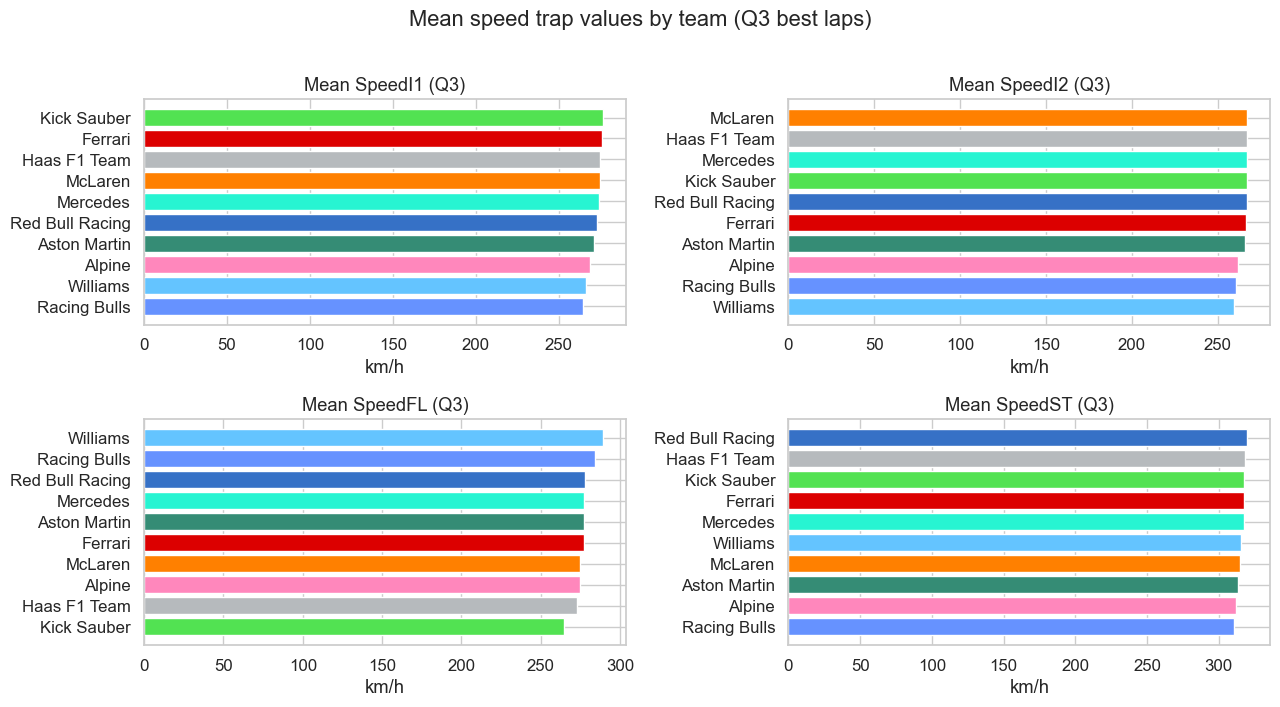

In [47]:
SPEED_COLS = ["SpeedI1","SpeedI2","SpeedFL","SpeedST"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, col in zip(axes.flatten(), SPEED_COLS):
    team_speed = (
        q3.groupby("Team")[col].mean()
            .sort_values(ascending=False)
    )
    bars = ax.barh(team_speed.index, team_speed.values,
                    color=[TEAM_PALETTE.get(t,"grey") for t in team_speed.index])
    ax.set(title=f"Mean {col} (Q3)", xlabel="km/h")
    ax.invert_yaxis()
plt.suptitle("Mean speed trap values by team (Q3 best laps)", y=1.01)
plt.tight_layout()
plt.show()


## Season-level trends

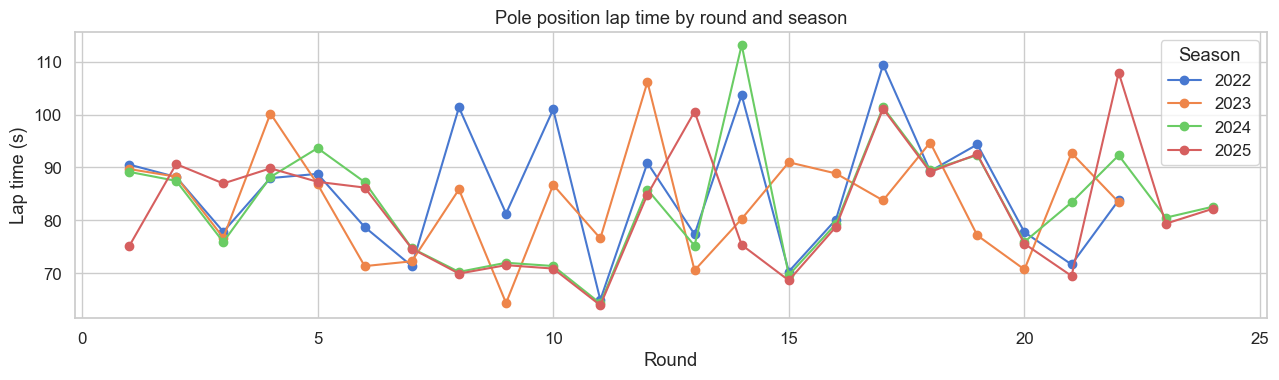

In [48]:
# Pole position (P1) lap time per round, coloured by year
pole = BEST[(BEST.SubSession=="Q3") & (BEST.GridPosition==1)].copy()

fig, ax = plt.subplots(figsize=(13, 4))
for year, grp in pole.groupby("Year"):
    ax.plot(grp["Round"], grp["LapTime_s"], marker="o", label=str(year))
ax.set(title="Pole position lap time by round and season",
       xlabel="Round", ylabel="Lap time (s)")
ax.legend(title="Season")
plt.tight_layout()
plt.show()


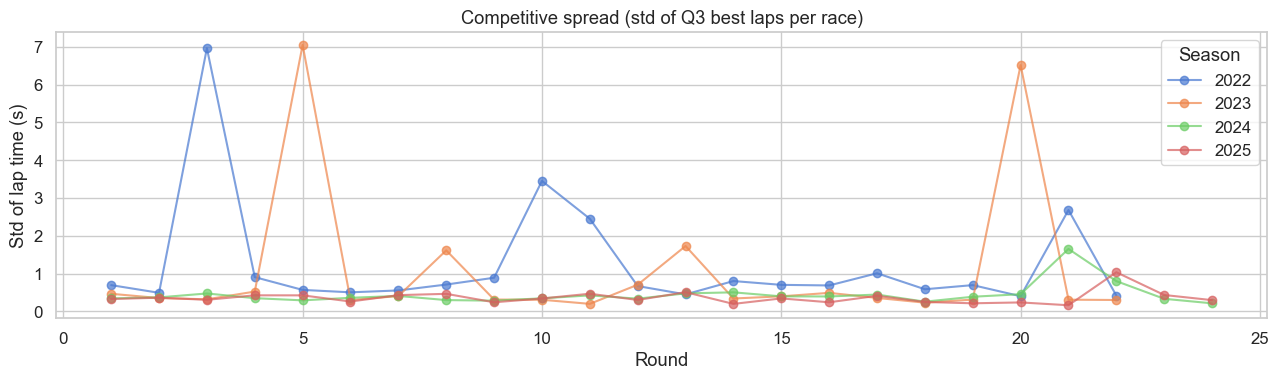

In [49]:
# Competitive spread: std of Q3 best laps per race
spread = (
    BEST[BEST.SubSession=="Q3"]
        .groupby(["Year","Round","Circuit"])["LapTime_s"]
        .std()
        .reset_index()
        .rename(columns={"LapTime_s":"Std_s"})
)
fig, ax = plt.subplots(figsize=(13, 4))
for year, grp in spread.groupby("Year"):
    ax.plot(grp["Round"], grp["Std_s"], marker="o", alpha=0.7, label=str(year))
ax.set(title="Competitive spread (std of Q3 best laps per race)",
       xlabel="Round", ylabel="Std of lap time (s)")
ax.legend(title="Season")
plt.tight_layout()
plt.show()


## Target variable: GridPosition

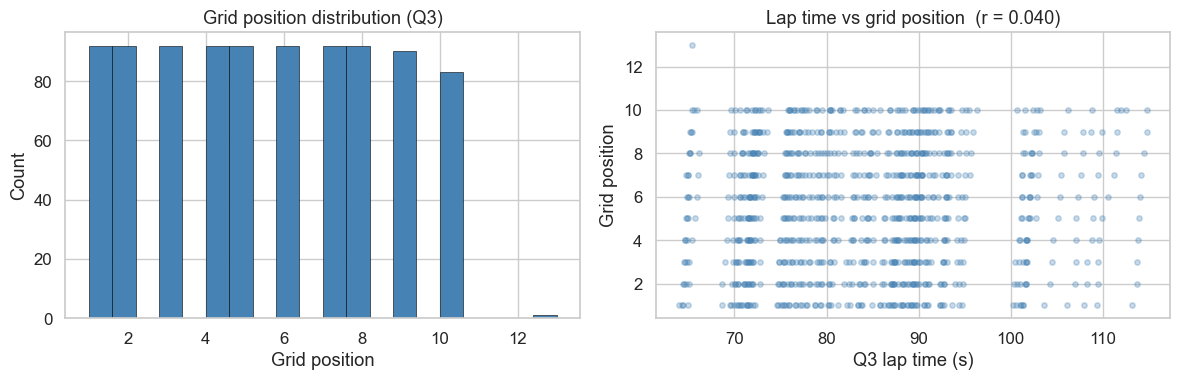

In [50]:
grid_q3 = BEST[BEST.SubSession=="Q3"]["GridPosition"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(grid_q3, bins=20, color="steelblue", edgecolor="black", linewidth=0.4)
axes[0].set(title="Grid position distribution (Q3)", xlabel="Grid position", ylabel="Count")

# lap time vs grid position
r, _ = stats.pearsonr(
    BEST[BEST.SubSession=="Q3"]["LapTime_s"],
    BEST[BEST.SubSession=="Q3"]["GridPosition"]
)
axes[1].scatter(
    BEST[BEST.SubSession=="Q3"]["LapTime_s"],
    BEST[BEST.SubSession=="Q3"]["GridPosition"],
    alpha=0.3, s=15, color="steelblue"
)
axes[1].set(title=f"Lap time vs grid position  (r = {r:.3f})",
            xlabel="Q3 lap time (s)", ylabel="Grid position")
plt.tight_layout()
plt.show()


## Outlier inspection

In [51]:
# Z-score based outlier flag on LapTime_s per circuit
from scipy.stats import zscore
df["z_LapTime"] = df.groupby("Circuit")["LapTime_s"].transform(zscore)
outliers = df[df["z_LapTime"].abs() > 3][
    ["Year","Round","Circuit","Driver","Team","SubSession","LapTime_s","z_LapTime","Wet"]
].sort_values("z_LapTime", key=abs, ascending=False)
print(f"Outliers (|z| > 3): {len(outliers)}")
outliers.head(20)


Outliers (|z| > 3): 14


,Year,Round,Circuit,Driver,Team,SubSession,LapTime_s,z_LapTime,Wet
1016,2023,1,BAHRAIN GRAND PRIX,ALB,Williams,Q2,125.534,12.611442,0
1205,2023,5,MIAMI GRAND PRIX,VER,Red Bull Racing,Q3,108.678,10.362815,0
2033,2024,2,SAUDI ARABIAN GRAND PRIX,ZHO,Kick Sauber,Q1,121.101,10.001226,0
490,2022,11,AUSTRIAN GRAND PRIX,HAM,Mercedes,Q3,73.151,9.626357,0
108,2022,3,AUSTRALIAN GRAND PRIX,STR,Aston Martin,Q1,106.833,8.283127,0
153,2022,4,GRAN PREMIO DEL MADE IN ITALY E DELL'EMILIA-RO...,ALB,Williams,Q1,123.171,8.196816,0
1823,2023,19,GRAN PREMIO DE LA CIUDAD DE MÉXICO,TSU,Racing Bulls,Q2,90.204,8.036823,0
1061,2023,2,SAUDI ARABIAN GRAND PRIX,VER,Red Bull Racing,Q2,109.953,6.513692,0
133,2022,3,AUSTRALIAN GRAND PRIX,ALO,Alpine,Q3,100.649,6.509528,0
1091,2023,3,AUSTRALIAN GRAND PRIX,PER,Red Bull Racing,Q1,100.187,6.377024,0
